We first import the relevant modules.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import normalize
from scipy.stats import shapiro
from scipy.optimize import curve_fit
from collections import Counter
from sklearn.linear_model import LinearRegression
from masterreg import linear_regression_assumptions

The following code makes graphs more pleasant.

In [2]:
sns.set()

We then import the datasets. `total.csv` and `unique.csv` contain data about total and unique views, respectively, from January/2019 to September/2022.

In [3]:
total_df = pd.read_csv('total.csv')
unique_df = pd.read_csv('unique.csv')

This first graph plots total views against time, homepage excluded. Thus, the second most visited page had more than 700 views during this timeframe; the last one in the rank had nearly none. It shows a clear exponencial decay, although the ragged structure of the middle of the curve indicates views are more stable along average rankings when compared to their more extreme counterparts.

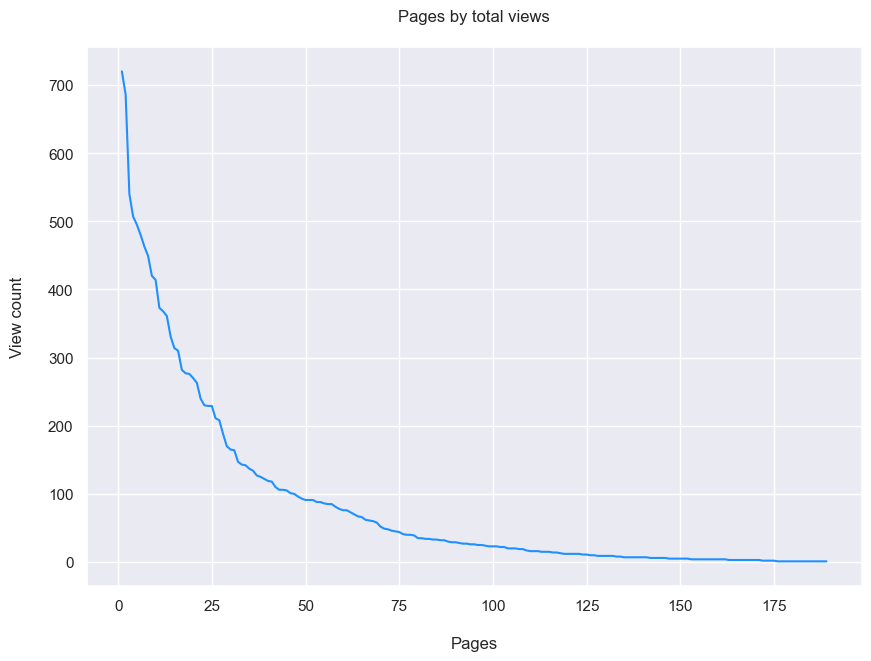

<Figure size 640x480 with 0 Axes>

In [4]:
plt.figure(figsize = (10,7))
plt.plot(total_df.iloc[1:], c = 'dodgerblue')
plt.title('Pages by total views\n')
plt.xlabel('\nPages')
plt.ylabel('View count\n')
plt.show()
plt.savefig('total.png', bbox_inches = 'tight', dpi = 300)

The data for unique views is cleaned here. Importantly, we only select articles for the `acceptable` variables.

In [5]:
unique_df['Date'] = pd.to_datetime(unique_df['Date'], format = '%m/%d/%Y')

acceptable_categories = ['business', 'people', 'podcasts']

URL_list = [i for i in unique_df['URL']]

second_slash = [i for i, letter in enumerate(URL_list[0]) if letter == '/'][1]

acceptable_URL = []

for url in URL_list:
    for cat in acceptable_categories:
        if url[second_slash:].find(cat) != -1:
            if len([i for i, letter in enumerate(url) if letter == '/']) > 3:
                acceptable_URL.append(url)
            
acceptable_unique = unique_df.query('URL == @acceptable_URL').reset_index().iloc[:,1:]

We'll now investigate the articles' life expectancy.

In [6]:
#Will select five random URLs and plot them against their entry amounts.
#rand_url = np.random.choice(acceptable_unique.shape[0], 5)
#rand_list = list(acceptable_unique.loc[rand_url]['URL'])
#rand_df = unique_df.query('URL == @rand_list').sort_values(by = ['URL', 'Date'])
#sns.relplot(data = rand_df, x = 'Date', y = 'UniqueViews', hue = 'URL', kind = 'line')

An article is said to have died if a certain sequence of its unique views' moving averages equals 1. The number of moving averages equal to 1 necessary to determine an article has died is set through `tolerance`.

In [7]:
def whendied(x, l, tolerance):
    for i, v in enumerate(x):
        if len(x) < 3:
            l.append(x[-1])
        else:
            if i + 2 < len(x):
                final = x[i]
                center = x[i + 1]
                start = x[i + 2]
                move = (final + center + start)/3
                l.append(move)
    if len(np.where(np.array(l) == 1.)[0]) != 0:
        return np.where(np.array(l) == 1.)[0][tolerance]
    else:
        if len(l) >= 2:
            return len(l)
        else:
            return 0

 We assign `tolerance = 0` for a conservative estimate.

In [8]:
death_records = []

for url in acceptable_unique['URL'].unique():
    unique_url = list(acceptable_unique.query('URL == @url')['UniqueViews'])
    death_records.append(whendied(unique_url, [], 0))
    
counts = Counter([i for i in death_records if i > 0])
count_df = pd.DataFrame.from_dict(counts, columns = ['Count'], orient='index')
count_df = count_df.reset_index()
count_df.columns = ['daystilldeath', 'count']

Let's plot the results.

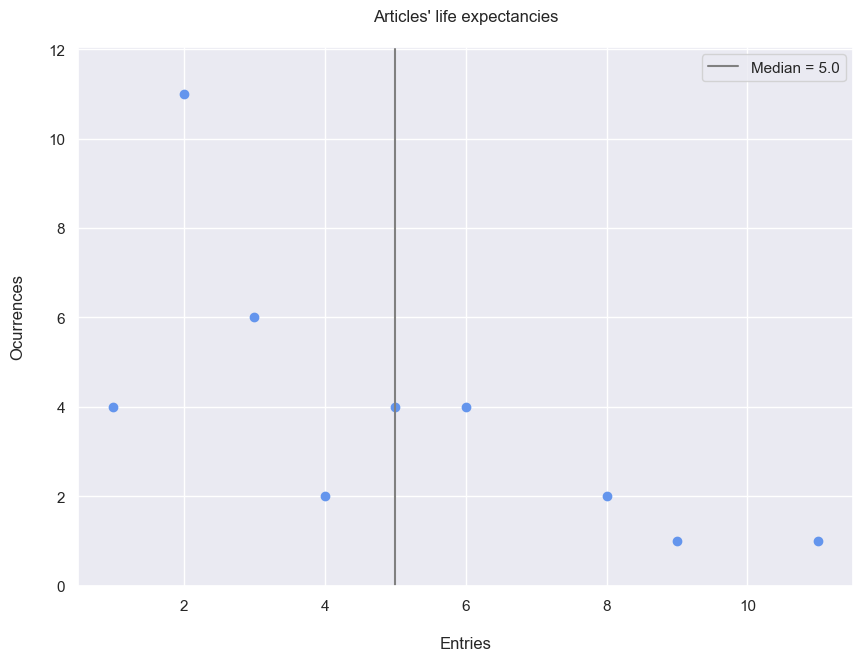

<Figure size 640x480 with 0 Axes>

In [9]:
cut = np.median(count_df['daystilldeath'])

Y_left = np.array(range(4))
Y_right = np.array(range(5, count_df['count'].max() + 2))
Y = np.concatenate([Y_left, Y_right])

plt.figure(figsize = (10,7))
plt.scatter(data = count_df, x = 'daystilldeath', y = 'count', c = 'cornflowerblue', label = '')
plt.ylim(0, Y[-1] + 0.05)
plt.plot([cut]*len(Y), Y, c = 'gray', label = 'Median = {}'.format(cut))
plt.legend()
plt.xlabel('\nEntries')
plt.ylabel('Ocurrences\n')
plt.title("Articles' life expectancies\n")
plt.show()
plt.savefig('scatter.png', bbox_inches = 'tight', dpi = 300)

As expected, there's a general negative relationship between life expectancy and ocurrences. However, there's also a great concentration around 2 entries, meaning most articles will peak at that point of engagement. We also see that half of the articles die after 5 entries, as indicated by the median line. We may now investigate this relationship in more detail.

Note: An entry represents an instance of a positive number of accesses. Consequently, an access on 2022/01/01 and another on 2022/01/03 count as two entries.

We'll start by removing the first entry in order to display a recurring theme. 

In [10]:
no_day_one = count_df.sort_values(by = 'daystilldeath').iloc[1:]

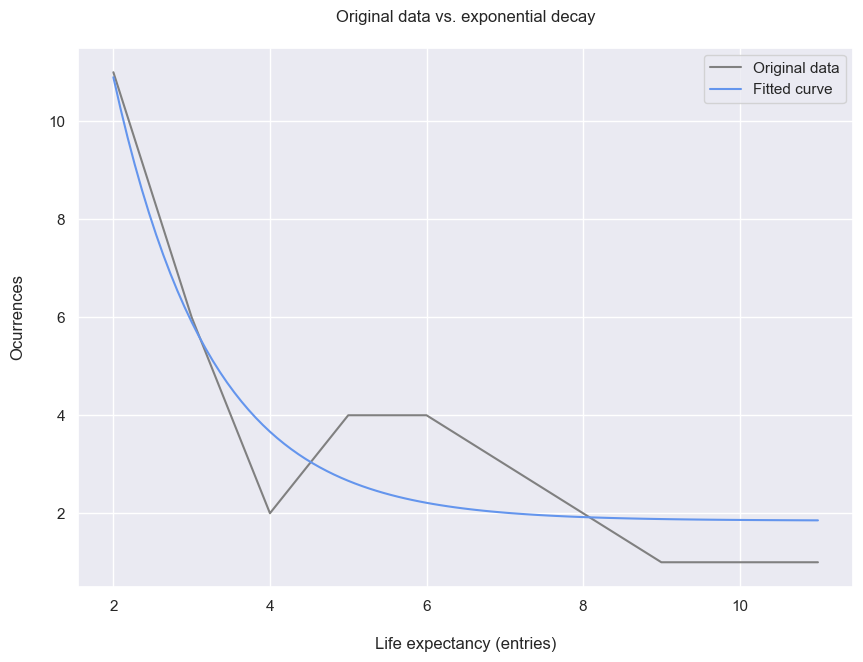

<Figure size 640x480 with 0 Axes>

In [11]:
popt, pcov = curve_fit(lambda t, j, k, l: j*np.exp(-k * t) + l, no_day_one['daystilldeath'].astype('float'), 
                       no_day_one['count'].astype('float'))

j = popt[0]
k = popt[1]
l = popt[2]

x_exp = np.linspace(2, max(count_df['daystilldeath']), 100)
y_exp = j*np.exp(-k * x_exp) + l

plt.figure(figsize = (10,7))
plt.plot(no_day_one['daystilldeath'], no_day_one['count'], c = 'grey', label = 'Original data')
plt.plot(x_exp, y_exp, c = 'cornflowerblue', label = 'Fitted curve')
plt.legend()
plt.title('Original data vs. exponential decay\n')
plt.xlabel('\nLife expectancy (entries)')
plt.ylabel('Ocurrences\n')
plt.show()
plt.savefig('fit.png', bbox_inches = 'tight', dpi = 300)

In [18]:
from math import e

In [21]:
#derivadas locais
(j*(-k)*(e**(-k*3)) - j*(-k)*(e**(-k*2)), j*(-k)*(e**(-k*11)) - j*(-k)*(e**(-k*10)))

(4.0122023295060405, 0.006504082181088521)

In [12]:
probdist = [i/sum(count_df['count']) for i in count_df['count']]

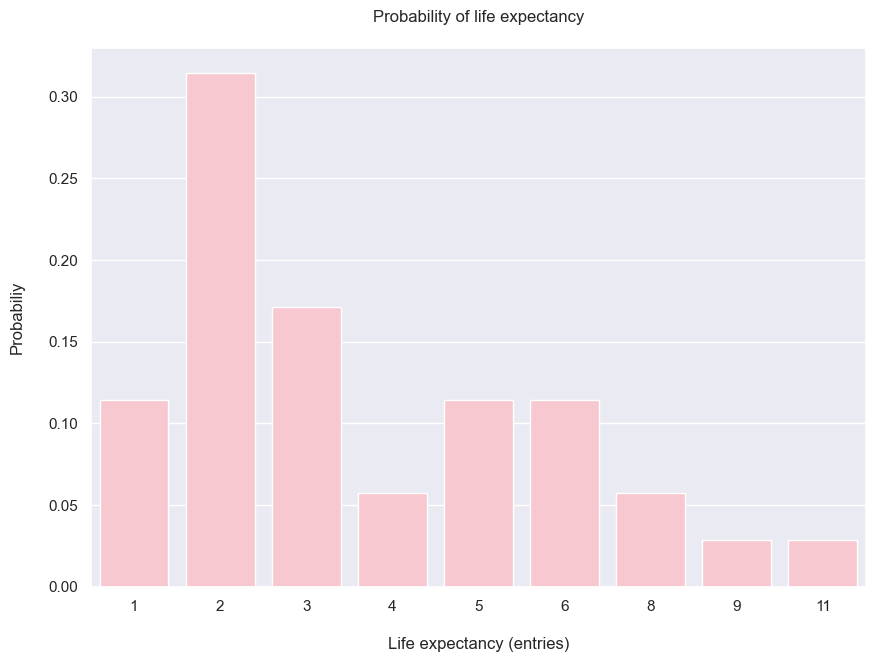

<Figure size 640x480 with 0 Axes>

In [13]:
plt.figure(figsize = (10,7))
sns.barplot(x = count_df['daystilldeath'], y = probdist, color = 'pink')
plt.title('Probability of life expectancy\n')
plt.xlabel('\nLife expectancy (entries)')
plt.ylabel('Probabiliy\n')
plt.show()
plt.savefig('dist.png', bbox_inches = 'tight', dpi = 300)